# Conférences Python Master TIDE #3bis

## Webscraping
## API

&copy; Francis Wolinski 2023

**Avec beautifulsoup** parsing HTML

Doc :
- beautifulsoup : https://www.crummy.com/software/BeautifulSoup/bs4/doc/

Installation :
- *pip install beautifulsoup4* ou *conda install -c anaconda beautifulsoup4*

In [1]:
# imports
from bs4 import BeautifulSoup

**Exemple basique**

In [2]:
html = """
<html>
    <head>
        <style>
        h1 { font-size: 50px; }
        body { font-family: Verdana; }
        li { color: red; }
        ul ul li { color: green; }
        .highlighted { font-weight: bold; }
        .italic { font-style: italic; }
        .highlighted.italic { }
        </style>
    </head>
    <body>
        <h1>Mon titre</h1>
        <p class="highlighted">
            Some text with a<br>
            <a href="https://google.com">link to google</a>
            <img src="https://picsum.photos/200/300">
        </p>
        <p>Some list:</p>
        <ul>
            <li>some item</li>
            <li class="highlighted italic">some item</li>
            <li class="italic">some item</li>
            <ul>
                <li>some other item 1</li>
                <li>some other item 2</li>
            </ul>
            <li>some item</li>
        </ul>
    </body>
</html>
"""

A tester sur : https://html.house

In [3]:
# bs4
soup = BeautifulSoup(html)
soup

<html>
<head>
<style>
        h1 { font-size: 50px; }
        body { font-family: Verdana; }
        li { color: red; }
        ul ul li { color: green; }
        .highlighted { font-weight: bold; }
        .italic { font-style: italic; }
        .highlighted.italic { }
        </style>
</head>
<body>
<h1>Mon titre</h1>
<p class="highlighted">
            Some text with a<br/>
<a href="https://google.com">link to google</a>
<img src="https://picsum.photos/200/300"/>
</p>
<p>Some list:</p>
<ul>
<li>some item</li>
<li class="highlighted italic">some item</li>
<li class="italic">some item</li>
<ul>
<li>some other item 1</li>
<li>some other item 2</li>
</ul>
<li>some item</li>
</ul>
</body>
</html>

In [4]:
# type
type(soup)

bs4.BeautifulSoup

In [5]:
# find h1
titre = soup.find('h1')
titre

<h1>Mon titre</h1>

In [6]:
# type
type(titre)

bs4.element.Tag

In [7]:
# name
titre.name

'h1'

In [8]:
# text
titre.text

'Mon titre'

In [9]:
# find a
link = soup.find('a')
link

<a href="https://google.com">link to google</a>

In [10]:
# prochain tag
link.find_next()

<img src="https://picsum.photos/200/300"/>

In [11]:
link.find_next().find_next()

<p>Some list:</p>

In [12]:
# attrs
link.attrs

{'href': 'https://google.com'}

In [13]:
# text
link.text

'link to google'

In [14]:
# find p
paragraph = soup.find('p')
paragraph

<p class="highlighted">
            Some text with a<br/>
<a href="https://google.com">link to google</a>
<img src="https://picsum.photos/200/300"/>
</p>

In [15]:
# find img in paragraph
paragraph.find('img')

<img src="https://picsum.photos/200/300"/>

In [16]:
# find_all
soup.find_all('li')

[<li>some item</li>,
 <li class="highlighted italic">some item</li>,
 <li class="italic">some item</li>,
 <li>some other item 1</li>,
 <li>some other item 2</li>,
 <li>some item</li>]

In [17]:
# find_all
soup.find_all('li', {'class': "italic"})

[<li class="highlighted italic">some item</li>,
 <li class="italic">some item</li>]

In [18]:
# idem avec un sélecteur css:
soup.select('li.italic')

[<li class="highlighted italic">some item</li>,
 <li class="italic">some item</li>]

In [19]:
# Récupérer les li de 2e niveau qui sont dans un ul lui-même dans un ul
soup.find('ul').find('ul').find_all('li')

[<li>some other item 1</li>, <li>some other item 2</li>]

In [ ]:
# idem avec un sélecteur css:
soup.select('ul ul li')

In [ ]:
# accès au premier li
li = soup.select('ul ul li')[0]
li

In [ ]:
# prochain tag identique
li.find_next_sibling()

In [ ]:
# parent
li.parent

In [ ]:
# contents
li.parent.contents

In [ ]:
# que les tags
li.parent.find_all()

**Exemple 1**

Le Bon Coin

In [21]:
# premier essai avec leboncoin
import requests
r = requests.get('https://www.leboncoin.fr/annonces/offres/ile_de_france/')
r

<Response [403]>

Codes erreurs du protocole HTTP : https://developer.mozilla.org/fr/docs/Web/HTTP/Status

In [22]:
# contenu
r.content

b'<html><head><title>leboncoin.fr</title><style>#cmsg{animation: A 1.5s;}@keyframes A{0%{opacity:0;}99%{opacity:0;}100%{opacity:1;}}</style></head><body style="margin:0"><p id="cmsg">Please enable JS and disable any ad blocker</p><script data-cfasync="false">var dd={\'rt\':\'c\',\'cid\':\'AHrlqAAAAAMAryCresTfgTYAXLhhCw==\',\'hsh\':\'05B30BD9055986BD2EE8F5A199D973\',\'t\':\'bv\',\'s\':2089,\'e\':\'a0a36034bc54be02f90bfb4b597ea46b55b1f74abf54bae1d1d2b01bda2b5845\',\'host\':\'geo.captcha-delivery.com\'}</script><script data-cfasync="false" src="https://ct.captcha-delivery.com/c.js"></script></body></html>\n'

In [23]:
# en str
print(r.content.decode('utf-8'))

<html><head><title>leboncoin.fr</title><style>#cmsg{animation: A 1.5s;}@keyframes A{0%{opacity:0;}99%{opacity:0;}100%{opacity:1;}}</style></head><body style="margin:0"><p id="cmsg">Please enable JS and disable any ad blocker</p><script data-cfasync="false">var dd={'rt':'c','cid':'AHrlqAAAAAMAryCresTfgTYAXLhhCw==','hsh':'05B30BD9055986BD2EE8F5A199D973','t':'bv','s':2089,'e':'a0a36034bc54be02f90bfb4b597ea46b55b1f74abf54bae1d1d2b01bda2b5845','host':'geo.captcha-delivery.com'}</script><script data-cfasync="false" src="https://ct.captcha-delivery.com/c.js"></script></body></html>



In [24]:
# headers
headers = requests.utils.default_headers()
headers.update({'User-Agent': 'Mozilla/5.0 (Windows NT 6.1; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/85.0.4183.121 Safari/537.36',
               'Accept-Language': 'fr,fr-FR;',})
headers

{'User-Agent': 'Mozilla/5.0 (Windows NT 6.1; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/85.0.4183.121 Safari/537.36', 'Accept-Encoding': 'gzip, deflate', 'Accept': '*/*', 'Connection': 'keep-alive', 'Accept-Language': 'fr,fr-FR;'}

In [25]:
# 2nd essai avec leboncoin
r = requests.get('https://www.leboncoin.fr/annonces/offres/ile_de_france/',
                 headers=headers)
r

<Response [403]>

**Exemple 2**

Craig List

In [26]:
# essai avec craigslist
r = requests.get('https://paris.craigslist.org/search/vac',
                 headers=headers)
r

<Response [200]>

In [ ]:
#with open('Paris Locations de vacances - craigslist.htm', 'rb') as f:
#    content = f.read()
#content

In [29]:
# BeautifulSoup
soup = BeautifulSoup(r.content)
soup

<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8"/>
<meta content="IE=Edge" http-equiv="X-UA-Compatible"/>
<meta content="width=device-width,initial-scale=1" name="viewport"/>
<meta content="craigslist" property="og:site_name"/>
<meta content="preview" name="twitter:card"/>
<meta content="Paris Locations de vacances - craigslist" property="og:title"/>
<meta content="Paris Locations de vacances - craigslist" name="description"/>
<meta content="Paris Locations de vacances - craigslist" property="og:description"/>
<meta content="https://paris.craigslist.org/search/vac" property="og:url"/>
<title>Paris Locations de vacances - craigslist</title>
<link href="https://paris.craigslist.org/search/vac" rel="canonical"/>
<link href="https://paris.craigslist.org/search/vac" hreflang="x-default" rel="alternate"/>
<script id="ld_searchpage_data" type="application/ld+json">
    {"@type":"SearchResultsPage","description":"Locations De Vacances in Paris, FR","breadcrumb":{"itemListElement":[{"@type":

On utilise 2 méthodes :
    
- `find(tag, attrs)` : trouve le premier tag avec les attributs spécifiés
- `findAll(tag, attrs)` : trouve tous les tags avec les attributs spécifiés

In [ ]:
# exploration du HTML
# tag li avec class="result-row"

li_tag = soup.find('li', attrs={'class': 'result-row'})
print(li_tag)

In [ ]:
# type
type(li_tag)

La technique consiste par exemple à alimenter une liste de dictionnaires avec les valeurs trouvées pour chaque item et ensuite à le transformer en DataFrame :
- soit en utilisant `tag.attrs['attr']` pour collecter la valeur attr du tag <tag attr=value>
- soit en utilisant `tag.text` pour collecter la valeur <tag>text</tag>
- éventuellement en recherchant dans un nouveau tag à l'intérieur d'un tag donné

In [38]:
# collecte des informations
# "data-pid"
# "time"
# "title"
# "price"
# "housing"
# "hood"
# "data-ids" (images)

rows = []

for li_tag in soup.findAll('li', attrs={'class': 'result-row'}):
    row = {}
    row['data-pid'] = li_tag.attrs['data-pid']
    t = li_tag.find('time')
    row['datetime'] = t.attrs['datetime']
    # à compléter
    span = li_tag.find('span', attrs={'class': 'result-price'})
    row['price'] = span.text
    span = li_tag.find('span', attrs={'class': 'result-hood'})
    row['hood'] = span.text if span is not None else ""
    span = li_tag.find('span', attrs={'class': 'housing'})
    row['housing'] = span.text
    rows.append(row)
    
rows

[{'data-pid': '7696796061',
  'datetime': '2023-12-11 22:38',
  'price': '€100',
  'hood': ' (VISTA)',
  'housing': '\n                    1br -\n                '},
 {'data-pid': '7695578591',
  'datetime': '2023-12-08 10:03',
  'price': '€50',
  'hood': ' (Paris, France)',
  'housing': '\n                    1br -\n                    230m2 -\n                '},
 {'data-pid': '7695579239',
  'datetime': '2023-12-08 08:55',
  'price': '€50',
  'hood': ' (Paris)',
  'housing': '\n                    1br -\n                    560m2 -\n                '},
 {'data-pid': '7695578000',
  'datetime': '2023-12-08 08:53',
  'price': '€50',
  'hood': ' (Rue Duvivier)',
  'housing': '\n                    1br -\n                    400m2 -\n                '},
 {'data-pid': '7695578418',
  'datetime': '2023-12-08 08:50',
  'price': '€50',
  'hood': ' (Paris, France)',
  'housing': '\n                    1br -\n                    570m2 -\n                '},
 {'data-pid': '7695577513',
  'date

In [39]:
# en DataFrame
import pandas as pd

df = pd.DataFrame(rows)
df

,data-pid,datetime,price,hood,housing
0,7696796061,2023-12-11 22:38,€100,(VISTA),\n 1br -\n
1,7695578591,2023-12-08 10:03,€50,"(Paris, France)",\n 1br -\n ...
2,7695579239,2023-12-08 08:55,€50,(Paris),\n 1br -\n ...
3,7695578000,2023-12-08 08:53,€50,(Rue Duvivier),\n 1br -\n ...
4,7695578418,2023-12-08 08:50,€50,"(Paris, France)",\n 1br -\n ...
5,7695577513,2023-12-08 08:43,€90,(Boulevard Saint-Germain),\n 2br -\n ...
6,7690096046,2023-11-21 22:54,€1 000,(Paris),\n 1br -\n ...
7,7689220899,2023-11-19 11:12,€2 000,(7th area),\n 1br -\n ...
8,7684511449,2023-11-06 01:55,€100,"(8 avenue Georges Mandel, 16th arr., 75116 Pa...",\n 2br -\n
9,7684508511,2023-11-06 01:24,€80,"(Paris, Ile-De-France)",\n 1br -\n


**Exercice 4**

Compléter le DataFrame (sauf images)

#### Inconvénients du web scraping:
- plutôt lent (car on parse potentiellement beaucoup de HTML inutile)
- ne donne pas les résultats attendus si une partie du contenu est intégré dynamiquement à la page via javascript
- un changement dans l'architecture du html ou du css (e.g: refonte du design du site) oblige à réécrire entièrement le programme

### API

Exemple: Deezer

Artiste : https://www.deezer.com/fr/artist/3037

Récupérer le nombre de fans d'un artiste avec requests :

In [40]:
import requests
from bs4 import BeautifulSoup
# request
artist = 3037
response = requests.get(f'https://www.deezer.com/fr/artist/{artist}')
soup = BeautifulSoup(response.content)
nb_fans = int(soup.find('div', id='naboo_artist_social_small').span.text)
nb_fans

924310

Récupérer le nombre de fans d'un artiste avec l'API :

Doc:
- https://pypi.org/project/deezer-python/

Installation :
- *pip install deezer-python*

Le terme "API" est très générique et peut désigner bien des choses, mais dans le jargon on l'utilise souvent pour désigner un service web qui renvoie non pas:
> des pages web au format HTML (destinées à être lues par un humain dans son navigateur)

mais:
> des données au format JSON (destinées à être traitées par un programme)

![img](https://miro.medium.com/max/4238/1*OcmVkcsM5BWRHrg8GC17iw.png)

Puisque les API sont dédiées à l'usage via des programmes, elles disposent en général d'une bonne documentation, et sont fiables et stables dans le temps. Tandis que sur des pages web HTML classiques, le design peut par exemple changer du jour au lendemain et rendre votre programme BeautifulSoup obsolète.

In [41]:
# API JSON
response = requests.get(f'https://api.deezer.com/artist/{artist}')
data = response.json()
data

{'id': 3037,
 'name': 'Genesis',
 'link': 'https://www.deezer.com/artist/3037',
 'share': 'https://www.deezer.com/artist/3037?utm_source=deezer&utm_content=artist-3037&utm_term=0_1702571791&utm_medium=web',
 'picture': 'https://api.deezer.com/artist/3037/image',
 'picture_small': 'https://e-cdns-images.dzcdn.net/images/artist/c0ed2cf09c7bf072111d614fc4557b66/56x56-000000-80-0-0.jpg',
 'picture_medium': 'https://e-cdns-images.dzcdn.net/images/artist/c0ed2cf09c7bf072111d614fc4557b66/250x250-000000-80-0-0.jpg',
 'picture_big': 'https://e-cdns-images.dzcdn.net/images/artist/c0ed2cf09c7bf072111d614fc4557b66/500x500-000000-80-0-0.jpg',
 'picture_xl': 'https://e-cdns-images.dzcdn.net/images/artist/c0ed2cf09c7bf072111d614fc4557b66/1000x1000-000000-80-0-0.jpg',
 'nb_album': 58,
 'nb_fan': 924311,
 'radio': True,
 'tracklist': 'https://api.deezer.com/artist/3037/top?limit=50',
 'type': 'artist'}

In [42]:
# nb_fan
data['nb_fan']

924311

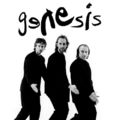

In [43]:
# picture
from IPython.display import Image
url = data['picture']
r = requests.get(url)
Image(data=r.content)

#### Avantages d'une API
- renvoie du format JSON, facile et rapide à traiter
- renvoie un format stable et documenté (voire versionné)
- exemple : https://developer.twitter.com/en/docs/twitter-api/api-reference-index
- la documentation indique comment interagir avec l'API:
    - quelle url
    - quelle méthode http (GET, POST, ...)
    - quels paramètres
    - ...
→ idéal pour les développeurs

### Quel intérêt pour le fournisseur d'API ?

En général il met en place des quotas de requêtes ou d'autres limitations afin de proposer un service payant qui dispose de possibilités avancées / d'un meilleur support / etc.

C'est pourquoi de nombreux services nécessitent de se connecter avec son compte client pour utiliser une API (e.g. https://openweathermap.org/api)

#### **Basic Auth**

Exemple: accéder à https://kim.fspot.org/private/

Pour y accéder il est nécessaire d'utiliser les credentials suivant:
- login: admin
- password: secret

Si on ne les passe pas (ou si on ne passe pas les bons), on a une erreur 401 (= unauthorized).

In [ ]:
# sans login/password
res = requests.get('https://kim.fspot.org/private')
res

In [ ]:
# avec login password
res = requests.get('https://kim.fspot.org/private', auth=('admin', 'secret'))
res

In [ ]:
# contenu
res.content.decode('utf-8')

In [ ]:
# YAML pour masquer auth crendentials

#### Auth par token

Exemple sur openweathermap :
- documentation: https://openweathermap.org/appid
- mes tokens: https://home.openweathermap.org/api_keys

In [ ]:
# requête avec un token
token = ''

Avantage des tokens:
- évite que les requêtes HTTP contiennent le mot de passe - à la place elles contiennent un token
- si je me fais "voler" un token, je peux le supprimer de mon compte
- certains services fournissent des token plus ou moins limités : ainsi je peux accepter de prêter un token à quelqu'un d'autre si je sais qu'il ne pourra en faire qu'un usage restreint (e.g app facebook: voir mes infos de profil, pas publier des posts à ma place)

In [ ]:
# requête avec un token
url = f'http://api.openweathermap.org/data/2.5/weather?APPID={token}&q=Paris'
res = requests.get(url)

meteo = res.json()
meteo

In [ ]:
# type
type(meteo)

In [ ]:
# extractions
{'city': meteo['name'],
'country': meteo['sys']['country'],
'date': meteo['dt'],
'temp': meteo['main']['temp'] - 273.15,}

In [ ]:
# extractions
import time

{'city': meteo['name'],
'country': meteo['sys']['country'],
'date': time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(meteo['dt'])),
'temp': meteo['main']['temp'] - 273.15,}